In [40]:
import pandas as pd
import numpy as np
import os
import glob
import re
from matplotlib import pyplot as plt
import  re

In [137]:
def printLatex(df):
    print(df.round(2).to_latex(
        float_format="%.5f",
        bold_rows=True,
        # caption="Statistical Comparison of Datasets"
    )
     )


def generate_dataset_statistics(df, name="Dataset"):
    """
    Generate comprehensive statistics for a dataset
    """
    stats_dict = {
        "Dataset Name": name,
        "Sample Size": len(df),
        "Features": df.shape[1],
        
        # Central Tendency
        "Mean": df.mean().mean(),
        "Median": df.median().mean(),
        "Mode": df.mode().iloc[0].mean(),
        
        # Dispersion
        "Std Dev": df.std().mean(),
        "Variance": df.var().mean(),
        "Range": (df.max() - df.min()).mean(),
        "IQR": (df.quantile(0.75) - df.quantile(0.25)).mean(),
        
        # Distribution
        "Skewness": df.skew().mean(),
        "Kurtosis": df.kurtosis().mean(),
        
        # Missing Values
        "Missing (%)": (df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100,
        
        # Confidence Intervals
        "95% CI Lower": df.mean().mean() - 1.96 * (df.std().mean() / np.sqrt(len(df))),
        "95% CI Upper": df.mean().mean() + 1.96 * (df.std().mean() / np.sqrt(len(df)))
    }
    
    return pd.Series(stats_dict)

# Example usage
def create_statistics_table(datasets_dict):
    """
    Create a comparison table for multiple datasets
    """
    stats_df = pd.DataFrame([
        generate_dataset_statistics(df, name)
        for name, df in datasets_dict.items()
    ])
    
    # Format the table for LaTeX
    return stats_df
    
    # .round(2).to_latex(
    #     float_format="%.2f",
    #     bold_rows=True,
    #     caption="Statistical Comparison of Datasets"
    # )


In [2]:
dirString = 'results' #results_0104
dirs = os.listdir(dirString)

In [3]:
# i=0
li = []
for dataset in dirs:
    path = dirString + '/'+ dataset
    directory = os.path.join(path)
    dir_list = os.listdir(path)
    for filex in dir_list:
        # for file in files:
       if filex.endswith(".csv"):
           file = filex
           # print(file)
           df = pd.read_csv(path + '/' +file, index_col=None, header=0)
           df['file'] = file
           df['data'] = dataset
           for dsc in file.split('-')[1:-1]:
               cat, num = re.findall('[a-z]*',dsc)[-2], re.findall('[\.0-9]*',dsc)[0]
               cat = cat if cat!= '' else 'client'
               num = num if num!= '' else np.nan
               df[cat] = float(num)
           li.append(df)
# print(li)

frame = pd.concat(li, axis=0, ignore_index=True)

frame['modelType'] = frame.file.apply(lambda x : x.split('-')[2])
frame.train_acc = frame.train_acc.apply(lambda x: [float(z) for z in re.findall('[\.0-9]*',x) if z != ''])
frame.test_acc = frame.test_acc.apply(lambda x: [float(z) for z in re.findall('[\.0-9]*',x) if z != ''])
frame['train_acc_train'] = frame.train_acc.apply(lambda x: x[0])
frame['train_acc_val'] = frame.train_acc.apply(lambda x: x[1])
frame['train_acc_test'] = frame.train_acc.apply(lambda x: x[2])
frame['test_acc_train'] = frame.test_acc.apply(lambda x: x[0])
frame['test_acc_val'] = frame.test_acc.apply(lambda x: x[1])
frame['test_acc_test'] = frame.test_acc.apply(lambda x: x[2])
frame = frame[(frame.modelType=='contrastive')]
frame = frame[[ 
        # 'file','modelType', 
        'data', 'client',
        'e', 'fl', 'pc', 'pl', 'rl',
        'train_acc_train', 'train_acc_val', 'train_acc_test', 'test_acc_train',
        'test_acc_val', 'test_acc_test']]

In [4]:
items = []
for item in frame[[ 'pc', 'pl', 'rl',]].drop_duplicates().values:
    itemx = frame[(frame.pc == item[0]) & (frame.pl == item[1]) & (frame.rl==item[2])]
    itemx.columns = [ 
        'data', 'client',
        'e', 'fl', 'pc', 'pl', 'rl',
        'train_prec' + '_pc' + str(item[0])+ 'pl' + str(item[1])+ 'rl' + str(item[2]), 
        'train_recall' + '_pc' + str(item[0])+ 'pl' + str(item[1])+ 'rl' + str(item[2]), 
        'train_f1' + '_pc' + str(item[0])+ 'pl' + str(item[1])+ 'rl' + str(item[2]), 
        'test_prec' + '_pc' + str(item[0])+ 'pl' + str(item[1])+ 'rl' + str(item[2]),
        'test_recall' + '_pc' + str(item[0])+ 'pl' + str(item[1])+ 'rl' + str(item[2]), 
        'test_f1' + '_pc' + str(item[0])+ 'pl' + str(item[1])+ 'rl' + str(item[2])
    ]
    itemx = itemx[[ 
        'data', 'client',
        'train_prec' + '_pc' + str(item[0])+ 'pl' + str(item[1])+ 'rl' + str(item[2]), 
        'train_recall' + '_pc' + str(item[0])+ 'pl' + str(item[1])+ 'rl' + str(item[2]), 
        'train_f1' + '_pc' + str(item[0])+ 'pl' + str(item[1])+ 'rl' + str(item[2]), 
        'test_prec' + '_pc' + str(item[0])+ 'pl' + str(item[1])+ 'rl' + str(item[2]),
        'test_recall' + '_pc' + str(item[0])+ 'pl' + str(item[1])+ 'rl' + str(item[2]), 
        'test_f1' + '_pc' + str(item[0])+ 'pl' + str(item[1])+ 'rl' + str(item[2])]
    ]
    # print(itemx.shape)
    items.append(itemx)

In [5]:
df = items[0]
for i, item in enumerate(items):
    if i == 0 : continue
    df = pd.merge(df, items[i], how='outer', on=["data","client"], suffixes=("", "_r"))

In [6]:
# df.groupby(['data']).mean()

In [7]:
dft = df.T
dft.columns= dft.iloc[0]
dft = dft.iloc[2:,:]
dft = dft.reset_index()
dft['cat'] = dft['index'].apply(lambda x : x.split('_')[-1])
dft['trainTest'] = dft['index'].apply(lambda x : ('_').join(x.split('_')[:-1]))
dft = dft.set_index(['cat','trainTest']).T.iloc[1:].reset_index()

In [8]:
# dft

In [9]:
dft = dft.T
dft.columns = dft.iloc[0]
dft = dft.iloc[1:]
dft = dft.reset_index()
# dft

In [10]:
z = dft[dft.trainTest=='train_f1'].set_index(['cat']).T.reset_index().iloc[1:]
z.columns = ['data',
             'pc0.2pl0.1rl1.0', #
             'pc0.5pl0.1rl1.0', #
             'pc0.2pl0.5rl1.0', #
             'pc0.5pl0.5rl1.0', # 
             'pc0.5pl0.1rl0.8',
             'pc0.5pl2.0rl1.0', #
             'pc0.2pl2.0rl0.8', 
             'pc0.5pl0.5rl0.8',
             'pc0.5pl2.0rl0.8', 
             'pc0.2pl0.5rl0.8', 
             'pc0.2pl0.1rl0.8',
             'pc0.2pl2.0rl1.0', #
             'pc0.0pl1.0rl1.0', #
             'pc0.2pl0.5rl0.2',
             'pc0.5pl2.0rl0.2', 
             'pc0.2pl0.1rl0.2', 
             'pc0.5pl0.1rl0.2',
             'pc0.5pl0.5rl0.2', 
             'pc0.2pl2.0rl0.2',
            ]
columnOrder = ['data',
             'pc0.0pl1.0rl1.0', #normal
               
             'pc0.2pl0.1rl1.0',
             'pc0.2pl0.1rl0.8', #random 0.8 low poison low skip
             'pc0.2pl0.1rl0.2', #random 0.2 low poison high skip
               
             'pc0.2pl0.5rl1.0',
             'pc0.2pl0.5rl0.8', #random 0.8
             'pc0.2pl0.5rl0.2', #random 0.2
               
             'pc0.2pl2.0rl1.0',
             'pc0.2pl2.0rl0.8', #random 0.8
             'pc0.2pl2.0rl0.2', #random 0.2
               
             'pc0.5pl0.1rl1.0',
             'pc0.5pl0.1rl0.8', #random 0.8 high poison low skip
             'pc0.5pl0.1rl0.2', #random 0.2 high poison high skip
               
             'pc0.5pl0.5rl1.0',
             'pc0.5pl0.5rl0.8', #random 0.8
             'pc0.5pl0.5rl0.2', #random 0.2
               
             'pc0.5pl2.0rl1.0',
             'pc0.5pl2.0rl0.8', #random 0.8
             'pc0.5pl2.0rl0.2', #random 0.2
            ]
z = z[columnOrder]
# .groupby([('data', '')]).mean()
final = z.groupby('data').mean()
final = final.fillna(0)
x = final.columns

/var/folders/md/17gxb5p94d5_f_nm_06qhsj40000gn/T/ipykernel_49176/3811821243.py:53: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final = final.fillna(0)


In [11]:
# final

In [12]:
textbox = []
for i, item in enumerate(columnOrder[1:]):
    textbox.append(' = '.join([str(i),item]))
# textbox

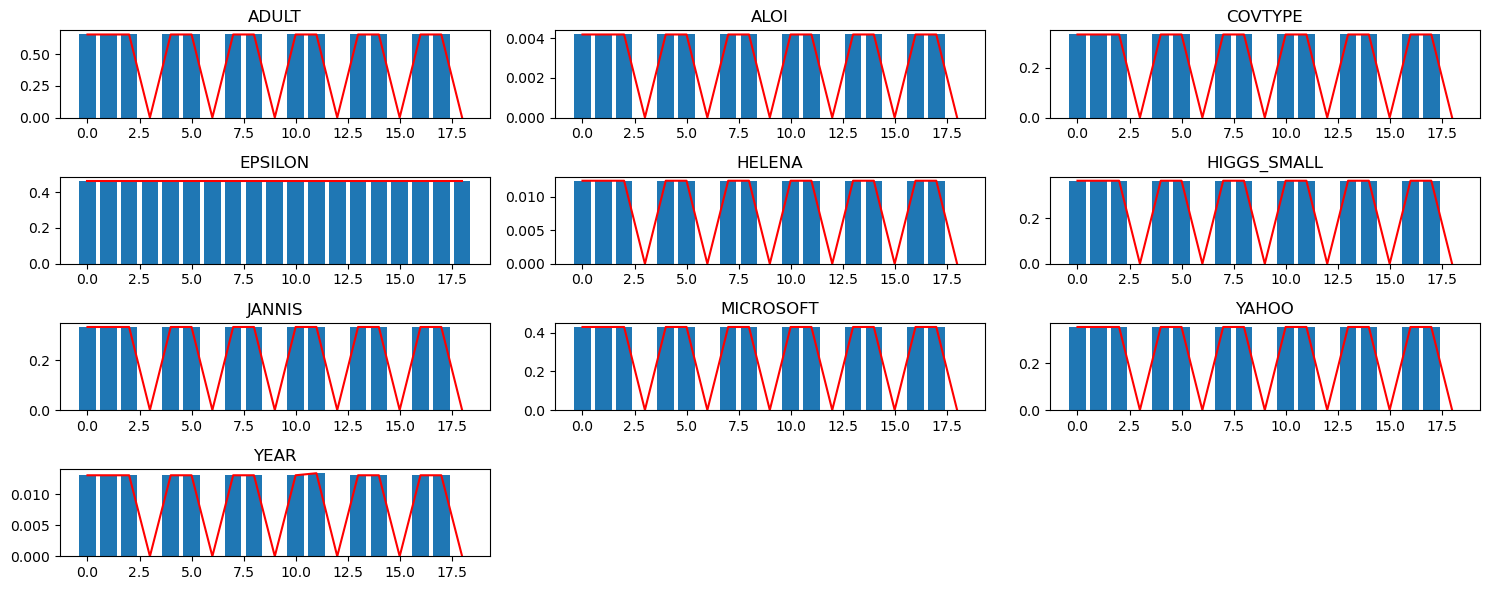

In [13]:
fig, axs = plt.subplots(4,3, figsize=(15, 6))
fig.subplots_adjust(hspace = .5, wspace=.001)

axs = axs.ravel()
for i in range(final.shape[0]):
    axs[i].bar(range(final.shape[1]),final.iloc[i])
    axs[i].plot(range(final.shape[1]),final.iloc[i], c='r')
    axs[i].title.set_text(final.index[i].upper())
for i in range(final.shape[0],12):
    axs[i].remove()

textbox = '\n'.join(textbox)

bbox = dict(boxstyle='square', facecolor='lavender', alpha=0.5)
# fig.text(1.1,1,textbox,fontsize=10,transform=axs[6].transAxes, bbox=bbox,verticalalignment='top')

plt.tight_layout()
plt.show()

In [78]:
# z.isna().sum(axis=0)
# z

In [52]:
x = z.set_index('data').isna().reset_index().groupby('data').agg('sum').T.reset_index()
# .plot(kind='bar')
# [x['pc'],x['pl'],x['rl']] = x['index'].apply(lambda x : re.split('[p,c,r,l]+',x)[1:])
x['pc'] = x['index'].apply(lambda x : re.split('[p,c,r,l]+',x)[1])
x['pl'] = x['index'].apply(lambda x : re.split('[p,c,r,l]+',x)[2])
x['rl'] = x['index'].apply(lambda x : re.split('[p,c,r,l]+',x)[3])
x = x[x.columns[1:] ]
x.columns

Index(['adult', 'aloi', 'covtype', 'epsilon', 'helena', 'higgs_small',
       'jannis', 'microsoft', 'yahoo', 'year', 'pc', 'pl', 'rl'],
      dtype='object', name='data')

In [101]:
pc = x[['adult', 'aloi', 'covtype', 'epsilon', 'helena', 'higgs_small',
       'jannis', 'microsoft', 'yahoo', 'year', 'pc']]
pc = pc.astype('float') / (8*19) *100
pc.pc = pc.pc * (8*19) / 100
pc = pc.groupby('pc').agg('sum').T
printLatex(pc)

\begin{tabular}{lrrr}
\toprule
pc & 0.000000 & 0.200000 & 0.500000 \\
data &  &  &  \\
\midrule
\textbf{adult} & 0.00 & 15.79 & 15.79 \\
\textbf{aloi} & 0.00 & 15.79 & 15.79 \\
\textbf{covtype} & 0.00 & 15.79 & 15.79 \\
\textbf{epsilon} & 0.00 & 0.00 & 0.00 \\
\textbf{helena} & 0.00 & 15.79 & 15.79 \\
\textbf{higgs_small} & 0.00 & 15.79 & 15.79 \\
\textbf{jannis} & 0.00 & 15.79 & 15.79 \\
\textbf{microsoft} & 0.00 & 15.79 & 15.79 \\
\textbf{yahoo} & 0.00 & 15.79 & 15.79 \\
\textbf{year} & 0.00 & 15.79 & 16.45 \\
\bottomrule
\end{tabular}



In [102]:
pl = x[['adult', 'aloi', 'covtype', 'epsilon', 'helena', 'higgs_small',
       'jannis', 'microsoft', 'yahoo', 'year', 'pl']]
pl = pl.astype('float') / (8*19) *100
pl.pl = pl.pl * (8*19) / 100
pl = pl.groupby('pl').agg('sum').T
printLatex(pl)

\begin{tabular}{lrrrr}
\toprule
pl & 0.100000 & 0.500000 & 1.000000 & 2.000000 \\
data &  &  &  &  \\
\midrule
\textbf{adult} & 10.53 & 10.53 & 0.00 & 10.53 \\
\textbf{aloi} & 10.53 & 10.53 & 0.00 & 10.53 \\
\textbf{covtype} & 10.53 & 10.53 & 0.00 & 10.53 \\
\textbf{epsilon} & 0.00 & 0.00 & 0.00 & 0.00 \\
\textbf{helena} & 10.53 & 10.53 & 0.00 & 10.53 \\
\textbf{higgs_small} & 10.53 & 10.53 & 0.00 & 10.53 \\
\textbf{jannis} & 10.53 & 10.53 & 0.00 & 10.53 \\
\textbf{microsoft} & 10.53 & 10.53 & 0.00 & 10.53 \\
\textbf{yahoo} & 10.53 & 10.53 & 0.00 & 10.53 \\
\textbf{year} & 11.18 & 10.53 & 0.00 & 10.53 \\
\bottomrule
\end{tabular}



In [103]:
rl = x[['adult', 'aloi', 'covtype', 'epsilon', 'helena', 'higgs_small',
       'jannis', 'microsoft', 'yahoo', 'year', 'rl']]
rl = rl.astype('float') / (8*19) *100
rl.rl = rl.rl * (8*19) / 100
rl = rl.groupby('rl').agg('sum').T
printLatex(rl)

\begin{tabular}{lrrr}
\toprule
rl & 0.200000 & 0.800000 & 1.000000 \\
data &  &  &  \\
\midrule
\textbf{adult} & 31.58 & 0.00 & 0.00 \\
\textbf{aloi} & 31.58 & 0.00 & 0.00 \\
\textbf{covtype} & 31.58 & 0.00 & 0.00 \\
\textbf{epsilon} & 0.00 & 0.00 & 0.00 \\
\textbf{helena} & 31.58 & 0.00 & 0.00 \\
\textbf{higgs_small} & 31.58 & 0.00 & 0.00 \\
\textbf{jannis} & 31.58 & 0.00 & 0.00 \\
\textbf{microsoft} & 31.58 & 0.00 & 0.00 \\
\textbf{yahoo} & 31.58 & 0.00 & 0.00 \\
\textbf{year} & 31.58 & 0.66 & 0.00 \\
\bottomrule
\end{tabular}



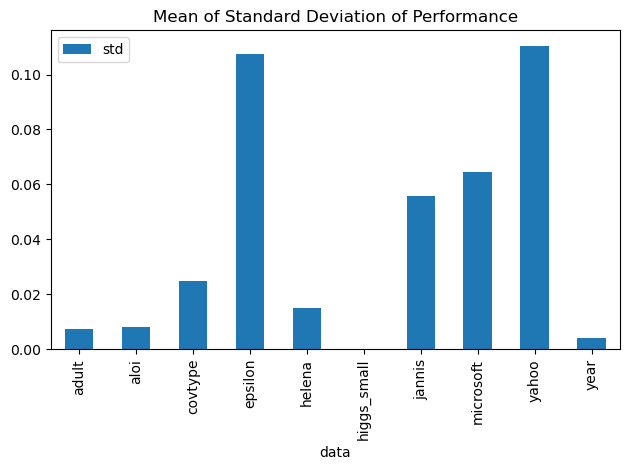

In [161]:
stdZ = z.groupby('data').std()[[ 'pc0.2pl0.1rl1.0', 'pc0.2pl0.1rl0.8',
        'pc0.2pl0.5rl1.0', 'pc0.2pl0.5rl0.8',
        'pc0.2pl2.0rl1.0', 'pc0.2pl2.0rl0.8',
        'pc0.5pl0.1rl1.0', 'pc0.5pl0.1rl0.8',
        'pc0.5pl0.5rl1.0', 'pc0.5pl0.5rl0.8',
        'pc0.5pl2.0rl1.0', 'pc0.5pl2.0rl0.8',
       ]].agg(['mean'], axis=1)
stdZ.columns = ['std']
stdZ.plot(subplots=True, kind='bar')
plt.title('Mean of Standard Deviation of Performance')
# plt.ylim(0, 1e-1)
# printLatex(stdZ)
plt.tight_layout()
plt.savefig('meanOfStd.png')

In [136]:
stdZ

,mean,std
data,,
adult,0.007221,1.811860e-18
aloi,0.008148,1.811860e-18
covtype,0.024869,3.623719e-18
epsilon,0.107415,0.000000e+00
helena,0.015050,3.623719e-18
higgs_small,0.000000,0.000000e+00
jannis,0.055808,0.000000e+00
microsoft,0.064407,1.449488e-17
yahoo,0.110564,1.449488e-17


In [145]:
z[z.data == 'higgs_small' ]

,data,pc0.0pl1.0rl1.0,pc0.2pl0.1rl1.0,pc0.2pl0.1rl0.8,pc0.2pl0.1rl0.2,pc0.2pl0.5rl1.0,pc0.2pl0.5rl0.8,pc0.2pl0.5rl0.2,pc0.2pl2.0rl1.0,pc0.2pl2.0rl0.8,pc0.2pl2.0rl0.2,pc0.5pl0.1rl1.0,pc0.5pl0.1rl0.8,pc0.5pl0.1rl0.2,pc0.5pl0.5rl1.0,pc0.5pl0.5rl0.8,pc0.5pl0.5rl0.2,pc0.5pl2.0rl1.0,pc0.5pl2.0rl0.8,pc0.5pl2.0rl0.2
41,higgs_small,0.363192,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN
42,higgs_small,0.363192,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN
43,higgs_small,0.363192,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN
44,higgs_small,0.363192,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN
45,higgs_small,0.363192,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN
46,higgs_small,0.363192,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN
47,higgs_small,0.363192,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN
48,higgs_small,0.363192,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN,0.363192,0.363192,NaN
